In [10]:
import torch
import torch.nn as nn 
import math
import random
import numpy as np
import cv2

In [16]:
def create_model(width=256, L=10): 
    input_dim = 2*(2*L + 1)
    return nn.Sequential(
        nn.Linear(input_dim, width), 
        nn.ReLU(),
        nn.Linear(width, width),
        nn.ReLU(),
        nn.Linear(width,width),
        nn.ReLU(),
        nn.Linear(width,3),
        nn.Sigmoid()
    )

In [ ]:
def PE(x, L=10): 
    #single coordinate 
    encoded = [x]

    for i in range(L):
        freq = 2**i * math.pi
        encoded.append(torch.sin(freq * x))
        encoded.append(torch.cos(freq * x))

    return torch.cat(encoded, dim=-1)

def positional_encoding_2d(coords, L = 10): 
    x, y = coords[..., 0:1], coords[..., 1:2]
    x_encoded = PE(x, L)
    y_encoded = PE(y, L)
    return torch.cat([x_encoded, y_encoded], dim=-1)

def Dataloader(image, N): 
    
    width, height = image.shape[1], image.shape[0]
    total_pixels = width * height
    batch_indices = np.random.choice(total_pixels, size=N, replace=False)
    
    batch_y = batch_indices // width
    batch_x = batch_indices % width

    batch_color = image[batch_y, batch_x]

    batch_coord_norm = np.column_stack([batch_x/width, batch_y/height])
    batch_color_norm = batch_color/ 255.0

    return batch_coord_norm, batch_color_norm

def compute_psnr(mse_loss):
    return 20 * torch.log10(1.0 / torch.sqrt(mse_loss))
    

In [54]:
import matplotlib.pyplot as plt 

def visualize_output(model, image_shape, L=10): 
    height,width = image_shape
    model.eval()

    with torch.no_grad(): 
        x= torch.linspace(0,1,width)
        y= torch.linspace(0,1,height)
        xx,yy = torch.meshgrid(x,y,indexing = 'xy')
        coords = torch.stack([xx,yy], dim=-1).reshape(-1,2) #(h,w,2) -> (h*w, 2)

        encoded_coords = positional_encoding_2d(coords, L=L)
        predicted_color = model(encoded_coords)
        output_image = predicted_color.reshape(height, width, 3).cpu().numpy()
        output_image = np.clip(output_image, 0, 1)
        
    plt.figure(figsize=(6, 6))  # Optional: adjust size as needed
    plt.imshow(output_image)
    #plt.title("Neural Field Output")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    
    model.train() 

In [61]:
def train_nerf_2d(width=256, L=10, learning_rate=1e-2, track_psnr=True): 
    image_path = "./fox.jpg"
    image = cv2.imread(image_path) 
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width_img = image.shape[:2] 

    model = create_model(width=width, L=L)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    psnr_values = []
    iteration_numbers = []

    for iteration in range(3000):

        coords, colors = Dataloader(image_rgb, 10000)
        
        coords_tensor = torch.FloatTensor(coords)
        colors_tensor = torch.FloatTensor(colors)

        encoded_coords = positional_encoding_2d(coords_tensor, L=L)


        predicted_colors = model(encoded_coords)
        loss = loss_fn(predicted_colors, colors_tensor)

        optimizer.zero_grad()

        loss.backward()  
        optimizer.step() 

        if track_psnr:
                psnr = compute_psnr(loss)
                psnr_values.append(psnr.item())
                iteration_numbers.append(iteration)

        if iteration % 100 == 0:
            print(f"Iteration {iteration}, Loss: {loss.item():.6f}, PSNR: {psnr.item():.2f} dB")

            # if iteration % 500 == 0:
            #     print("Generating visualization...")
            #     visualize_output(model, (height, width_img), L=L)
    print("Final result visualization...")
    visualize_output(model, (height, width_img), L=L)
    return  model, psnr_values, iteration_numbers

Iteration 0, Loss: 0.104295, PSNR: 9.82 dB
Iteration 100, Loss: 0.029081, PSNR: 15.36 dB
Iteration 200, Loss: 0.023711, PSNR: 16.25 dB
Iteration 300, Loss: 0.021695, PSNR: 16.64 dB
Iteration 400, Loss: 0.019548, PSNR: 17.09 dB
Iteration 500, Loss: 0.019105, PSNR: 17.19 dB
Iteration 600, Loss: 0.017651, PSNR: 17.53 dB
Iteration 700, Loss: 0.017369, PSNR: 17.60 dB
Iteration 800, Loss: 0.017884, PSNR: 17.48 dB
Iteration 900, Loss: 0.016346, PSNR: 17.87 dB
Iteration 1000, Loss: 0.015943, PSNR: 17.97 dB
Iteration 1100, Loss: 0.015980, PSNR: 17.96 dB
Iteration 1200, Loss: 0.015324, PSNR: 18.15 dB
Iteration 1300, Loss: 0.016206, PSNR: 17.90 dB
Iteration 1400, Loss: 0.015419, PSNR: 18.12 dB
Iteration 1500, Loss: 0.015005, PSNR: 18.24 dB
Iteration 1600, Loss: 0.015479, PSNR: 18.10 dB
Iteration 1700, Loss: 0.015567, PSNR: 18.08 dB
Iteration 1800, Loss: 0.015387, PSNR: 18.13 dB
Iteration 1900, Loss: 0.015368, PSNR: 18.13 dB
Iteration 2000, Loss: 0.015022, PSNR: 18.23 dB
Iteration 2100, Loss: 0.01

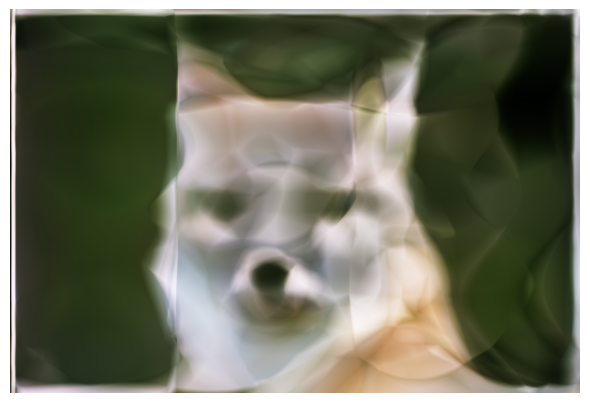

In [72]:
model, psnr_values, iterations = train_nerf_2d(width=16, L=3, learning_rate=1e-2)

In [73]:
def plot_psnr_curve(iteration_numbers, psnr_values, title="PSNR vs Iterations"):
    plt.figure(figsize=(10, 6))
    plt.plot(iteration_numbers, psnr_values, 'b-', linewidth=1, marker='o', markersize=1)
    plt.xlabel('Iteration')
    plt.ylabel('PSNR (dB)')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('psnr_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print some statistics
    print(f"Initial PSNR: {psnr_values[0]:.2f} dB")
    print(f"Final PSNR: {psnr_values[-1]:.2f} dB")
    print(f"PSNR Improvement: {psnr_values[-1] - psnr_values[0]:.2f} dB")

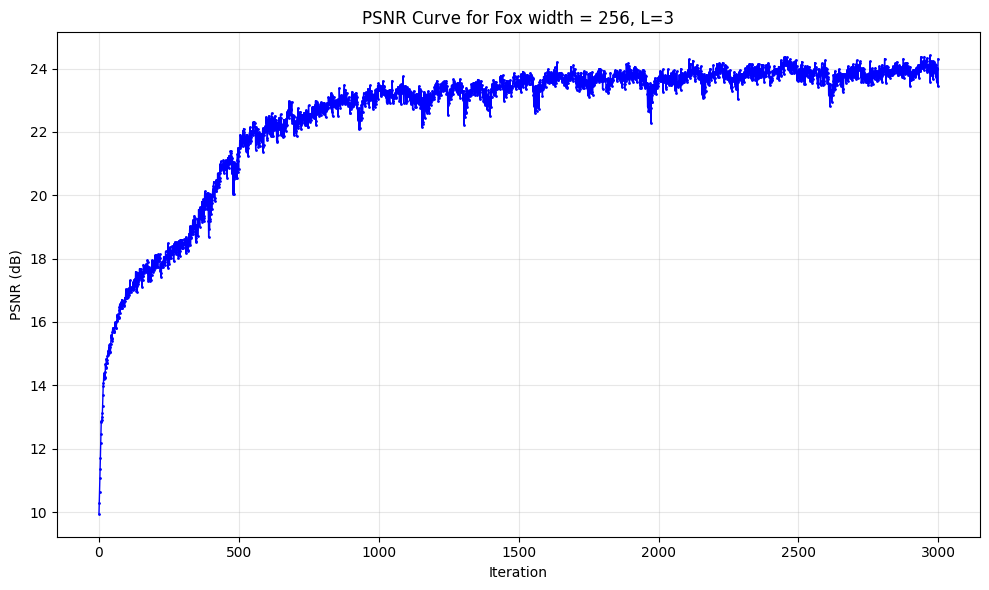

Initial PSNR: 9.95 dB
Final PSNR: 24.30 dB
PSNR Improvement: 14.36 dB


In [67]:
plot_psnr_curve(iterations, psnr_values, title="PSNR Curve for Fox width = 256, L=3")


array([[[-1.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00],
        [-0.00000000e+00,  5.00000000e-01, -8.66025404e-01,
          3.46410162e+00],
        [-0.00000000e+00, -8.66025404e-01, -5.00000000e-01,
          2.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]],

       [[-9.94521895e-01,  5.22642316e-02, -9.05243046e-02,
          3.62097218e-01],
        [ 1.04528463e-01,  4.97260948e-01, -8.61281226e-01,
          3.44512490e+00],
        [-3.05629239e-18, -8.66025404e-01, -5.00000000e-01,
          2.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]],

       [[-9.78147601e-01,  1.03955845e-01, -1.80056806e-01,
          7.20227224e-01],
        [ 2.07911691e-01,  4.89073800e-01, -8.47100671e-01,
          3.38840268e+00],
        [ 1.47701735e-17, -8.66025404e-01, -5.00000000e-01,
          2.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+